L’objectif de cette séance pratique est de découvrir Python et Scikit-Learn, une bibliothèque permettant d’exécuter différents modèles d’apprentissage automatique et de les utiliser pour résoudre des problèmes d’intelligence artificielle et de science des données.

## Régression linéaire et k-NN : réalisation sans bibliothèque

Nous allons écrire un premier programme pour calculer les coefficients d’une droite de régression, puis un second programme pour calculer les k plus proches voisins (k-NN) d’un point donné.

### Régression linéaire

Commençons avec un jeu de données simple :

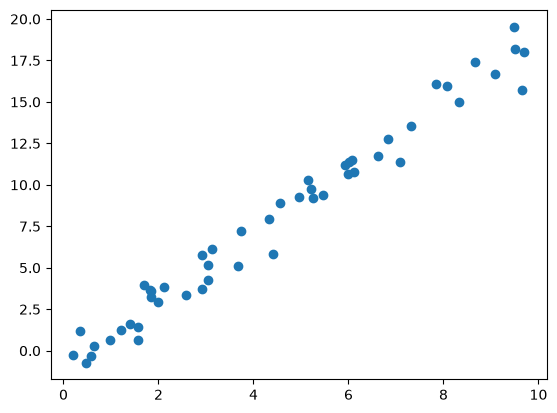

In [3]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.RandomState(42)
x = 10 * rng.rand(50)
y = 2 * x - 1 + rng.randn(50)
plt.scatter(x, y)

$\rightarrow$ Affichez les valeurs de x et de y. Quels sont les types de x et de y ? Quelle est leur relation ? Quel est le niveau de bruit dans cette relation ?

In [8]:
print("x:", x)
print("y:", y)

x: [3.74540119 9.50714306 7.31993942 5.98658484 1.5601864  1.5599452
 0.58083612 8.66176146 6.01115012 7.08072578 0.20584494 9.69909852
 8.32442641 2.12339111 1.81824967 1.8340451  3.04242243 5.24756432
 4.31945019 2.9122914  6.11852895 1.39493861 2.92144649 3.66361843
 4.56069984 7.85175961 1.99673782 5.14234438 5.92414569 0.46450413
 6.07544852 1.70524124 0.65051593 9.48885537 9.65632033 8.08397348
 3.04613769 0.97672114 6.84233027 4.40152494 1.22038235 4.9517691
 0.34388521 9.09320402 2.58779982 6.62522284 3.11711076 5.20068021
 5.46710279 1.84854456]
y: [ 7.22926896 18.18565441 13.52423055 10.67206599  0.64185082  1.4000462
 -0.29896653 17.38064514 11.36591852 11.3984114  -0.26422614 18.01311476
 14.97193082  3.8584585   3.66749887  3.59937032  4.24562734  9.18591626
  7.9701638   5.80012793 10.75788366  1.60421824  3.736558    5.13103024
  8.93392551 16.05975926  2.92146552 10.28822167 11.2099274  -0.7161115
 11.51229264  3.94851904  0.26520582 19.5423544  15.69289556 15.98984947



Nous voulons maintenant trouver la relation entre x et y uniquement à partir des points observés. Nous pouvons supposer différentes relations possibles (modèles) : linéaire, polynomiale de degré 2, spline, ... puis apprendre les paramètres de ces modèles à partir des données. Nous allons commencer par le modèle le plus simple, le modèle linéaire, qui suppose que la relation est de la forme :

\begin{equation*}
 y = ax + b,
\end{equation*}

où $a$ et $b$ sont des nombres réels, appelés respectivement pente et ordonnée à l’origine (ou biais). Apprendre le modèle revient donc à déterminer les valeurs de $a$ et $b$ à partir des données observées (nous noterons $\hat{a}$ et $\hat{b}$ les valeurs de $a$ et $b$ apprises à partir des données observées).

Nous devons néanmoins guider l’apprentissage en indiquant certaines propriétés de la droite recherchée. En régression linéaire, nous exigeons que la droite apprise soit aussi proche que possible des données observées. Par « aussi proche que possible », nous entendons que la somme des carrés des résidus doit être aussi petite que possible (cette méthode est parfois appelée MCO, pour moindres carrés ordinaires, ou OLS en anglais). Le résidu est défini comme l’erreur commise lorsque y est approché par une relation linéaire. Si nous avons observé $n$ points $(x_i,y_i)_{1 \le i \le n}$, la somme des résidus vaut :

\begin{equation*}
 \sum_{i=1}^{n}(y_i - a x_i - b)^2.
\end{equation*}

Le problème d’optimisation ci-dessus conduit à la solution suivante (nous le démontrerons plus tard dans le cours), où $\bar{x}$ et $\bar{y}$ désignent les moyennes de x et y :

\begin{align}
 \hat{a} = & \frac{\sum_{i=1}^{n}(x_i - \bar{x}) (y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}, \\
 \hat{b} = & \bar{y} - \hat{a} \bar{x}.
\end{align}

$\rightarrow$ Écrivez un programme qui calcule les coefficients de la droite (pente et ordonnée à l’origine), puis tracez la droite avec les points de données d’origine.

$\rightarrow$ Comment utiliser les résultats précédents pour prédire la valeur de y de nouveaux points dont nous connaissons uniquement x ?

### k plus proches voisins (k-NN) sur le jeu de données Iris

Nous allons maintenant implémenter un programme capable de prédire la classe d’un nouvel exemple à partir des classes connues de plusieurs exemples. Les exemples dont les étiquettes sont connues constituent l’<span style="color:green">ensemble d’apprentissage</span>.

Pour cela, nous allons utiliser le jeu de données Iris, qui contient des exemples à 4 dimensions (les dimensions correspondent à la longueur du sépale, la largeur du sépale, la longueur du pétale et la largeur du pétale), associés à une étiquette de classe parmi trois espèces d’iris possibles.

Pour chaque nouvel exemple dont l’étiquette de classe est inconnue, l’algorithme des $k$ plus proches voisins (k-NN) consiste à retrouver les $k$ voisins les plus proches dans l’ensemble d’apprentissage (en utilisant ici leur représentation à 4 dimensions), puis à attribuer au nouvel exemple la classe majoritaire parmi ces $k$ voisins.

$\rightarrow$ Vous devez écrire un programme capable de prédire l’étiquette de classe d’exemples qui ne font pas partie de l’ensemble d’apprentissage (cet ensemble d’exemples sera appelé <span style="color:green">ensemble de test</span> dans la suite). La valeur de $k$ doit être un argument de votre programme, afin que vous puissiez l’essayer avec différentes valeurs. Vous utiliserez la distance euclidienne standard pour mesurer la distance entre les points et sélectionner les $k$ points les plus proches.

Le jeu de données Iris peut être chargé et séparé en parties d’apprentissage et de test à l’aide des commandes suivantes :

In [ ]:
from sklearn.datasets import load_iris
dataset = load_iris()
X_iris = dataset.data
y_iris = dataset.target

In [ ]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, y_iris,
                                                random_state=10)

## Même démarche (et davantage) avec Scikit-Learn

L’API Scikit-Learn repose sur les principes directeurs suivants, présentés dans l’article consacré à l’API Scikit-Learn :

* Cohérence : tous les objets partagent une interface commune fondée sur un nombre limité de méthodes, avec une documentation cohérente.

* Inspection : toutes les valeurs de paramètres spécifiées sont accessibles sous forme d’attributs publics.

* Hiérarchie d’objets limitée : seuls les algorithmes sont représentés par des classes Python ; les jeux de données sont représentés dans des formats standards (tableaux NumPy, DataFrames Pandas, matrices creuses SciPy) et les noms des paramètres utilisent des chaînes Python standard.

* Composition : de nombreuses tâches d’apprentissage automatique peuvent être exprimées comme des suites d’algorithmes plus fondamentaux, et Scikit-Learn utilise cette possibilité chaque fois que c’est pertinent.

* Valeurs par défaut pertinentes : lorsque les modèles nécessitent des paramètres définis par l’utilisateur, la bibliothèque fournit une valeur par défaut appropriée.

En pratique, ces principes rendent Scikit-Learn très facile à utiliser une fois les principes de base compris. Chaque algorithme d’apprentissage automatique de Scikit-Learn est implémenté via l’API Estimator, qui fournit une interface cohérente pour un large éventail d’applications d’apprentissage automatique.

Les étapes les plus courantes pour utiliser l’API Estimator de Scikit-Learn sont les suivantes (nous détaillerons plusieurs exemples dans les sections qui suivent).

* Choisir une classe de modèle en important la classe d’estimateur appropriée depuis Scikit-Learn.
* Choisir les hyperparamètres du modèle en instanciant cette classe avec les valeurs souhaitées.
* Organiser les données sous forme de matrice de caractéristiques et de vecteur cible, conformément à la présentation précédente.
* Ajuster le modèle aux données en appelant la méthode fit() de l’instance du modèle.
* Appliquer le modèle à de nouvelles données :
  * En apprentissage supervisé, on prédit souvent les étiquettes de données inconnues à l’aide de la méthode predict().
  * En apprentissage non supervisé, on transforme souvent les données ou on en déduit certaines propriétés à l’aide de la méthode transform() ou predict().

Nous allons maintenant parcourir plusieurs exemples simples d’application de méthodes d’apprentissage supervisé et non supervisé.

### Régression linéaire

Comme exemple de ce processus, considérons une régression linéaire simple, c’est-à-dire le cas courant où l’on ajuste une droite aux données $(x,y)$. Nous utiliserons les mêmes données simples que précédemment pour notre exemple de régression :

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.RandomState(42)
x = 10 * rng.rand(50)
y = 2 * x - 1 + rng.randn(50)
plt.scatter(x, y)
print("x:",x)
print("y:", y)

Parcourons maintenant le processus de construction d’un modèle de régression linéaire (le processus est le même pour tous les modèles d’apprentissage automatique).

1. Choisir une classe de modèle

Dans Scikit-Learn, chaque classe de modèle est représentée par une classe Python. Ainsi, si nous souhaitons calculer un modèle de régression linéaire simple, nous pouvons importer la classe de régression linéaire :

In [ ]:
from sklearn.linear_model import LinearRegression

2. Choisir les hyperparamètres du modèle

Il est important de comprendre qu’une classe de modèle n’est pas la même chose qu’une instance de modèle.

Une fois la classe de modèle choisie, plusieurs options restent ouvertes. Selon la classe de modèle utilisée, nous pouvons devoir répondre à une ou plusieurs questions comme les suivantes :

Souhaitons-nous ajuster le décalage (c’est-à-dire l’ordonnée à l’origine) ?
Souhaitons-nous normaliser le modèle ?
Souhaitons-nous prétraiter nos caractéristiques pour rendre le modèle plus flexible ?
Quel degré de régularisation souhaitons-nous utiliser dans notre modèle ?
Combien de composantes du modèle souhaitons-nous utiliser ?

Ce sont des exemples de choix importants à effectuer une fois la classe du modèle sélectionnée. Ces choix sont souvent représentés par des hyperparamètres, c’est-à-dire des paramètres qui doivent être définis avant l’ajustement du modèle aux données. Dans Scikit-Learn, les hyperparamètres sont choisis en transmettant des valeurs lors de l’instanciation du modèle. Nous verrons plus tard comment justifier quantitativement le choix des hyperparamètres.

Pour notre exemple de régression linéaire, nous pouvons instancier la classe LinearRegression et préciser que nous souhaitons ajuster l’ordonnée à l’origine à l’aide de l’hyperparamètre fit_intercept :

In [ ]:
model = LinearRegression(fit_intercept=True)
model

$\rightarrow$ Expliquez l’hyperparamètre fit_intercept.

Gardez à l’esprit que lors de l’instanciation du modèle, la seule action effectuée consiste à mémoriser les valeurs de ces hyperparamètres. En particulier, nous n’avons pas encore appliqué le modèle à des données : l’API Scikit-Learn distingue clairement le choix du modèle et l’application du modèle aux données.

3. Organiser les données sous forme de matrice de caractéristiques et de vecteur cible

Nous avons précédemment détaillé la représentation des données dans Scikit-Learn, qui nécessite une matrice de caractéristiques à deux dimensions et un tableau cible à une dimension. Ici, notre variable cible y est déjà dans le bon format (un tableau de longueur n_samples), mais nous devons transformer les données x pour en faire une matrice de taille [n_samples, n_features]. Dans ce cas, il suffit de remodeler le tableau à une dimension :

In [ ]:
X = x[:, np.newaxis]
X.shape

4. Ajuster le modèle aux données

Il est maintenant temps d’appliquer notre modèle aux données. Cela se fait avec la méthode fit() du modèle :

In [ ]:
model.fit(X, y)

Cette commande fit() déclenche un certain nombre de calculs internes qui dépendent du modèle, et les résultats de ces calculs sont stockés dans des attributs propres au modèle que l’utilisateur peut explorer. Dans Scikit-Learn, par convention, tous les paramètres du modèle appris lors de l’ajustement fit() se terminent par un tiret bas ; par exemple, pour ce modèle linéaire, nous avons les suivants :

In [ ]:
model.coef_
model.intercept_

Ces deux paramètres représentent la pente et l’ordonnée à l’origine de l’ajustement linéaire simple aux données. En les comparant à la définition des données, nous constatons qu’ils sont très proches de la pente initiale 2 et de l’ordonnée à l’origine -1.

5. Prédire les étiquettes de données inconnues

Une fois le modèle entraîné, la tâche principale de l’apprentissage automatique supervisé consiste à l’évaluer à partir de ses prédictions sur de nouvelles données qui ne faisaient pas partie de l’ensemble d’apprentissage. Dans Scikit-Learn, cela peut se faire avec la méthode predict(). Pour cet exemple, nos « nouvelles données » seront une grille de valeurs de x, et nous demanderons quelles valeurs de y le modèle prédit :

In [ ]:
xfit = np.linspace(-1, 11)
print("xfit: ",xfit)

$\rightarrow$ Quel est l’effet de linspace ?

Comme précédemment, nous devons transformer ces valeurs de x en une matrice de caractéristiques de taille [n_samples, n_features], puis nous pouvons les transmettre au modèle :

In [ ]:
Xfit = xfit[:, np.newaxis]
yfit = model.predict(Xfit)
print("Xfit: ",Xfit)
print("yfit: ",yfit)

$\rightarrow$ Quel est l’effet de xfit[:, np.newaxis] ? De model.predict(Xfit) ? Quels sont les types de Xfit et de yfit ?

Enfin, visualisons les résultats en traçant d’abord les données brutes, puis cet ajustement du modèle :

In [ ]:
plt.scatter(x, y)
plt.plot(xfit, yfit);

### k plus proches voisins sur le jeu de données Iris

Examinons un autre exemple de ce processus, en utilisant le jeu de données Iris. Notre question sera la suivante : étant donné un modèle entraîné sur une partie des données Iris, dans quelle mesure pouvons-nous prédire les étiquettes restantes ?

Pour cette tâche, nous utiliserons un algorithme extrêmement simple appelé algorithme des $k$ plus proches voisins (voir ci-dessus). Nous voulons évaluer le modèle sur des données qu’il n’a jamais vues auparavant ; nous allons donc séparer les données en un ensemble d’apprentissage et un ensemble de test. Cela pourrait être fait manuellement, mais il est plus pratique d’utiliser la fonction utilitaire train_test_split :

In [ ]:
from sklearn.datasets import load_iris
dataset = load_iris()
X_iris = dataset.data
y_iris = dataset.target

In [ ]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, y_iris,
                                                random_state=10)

$\rightarrow$ À quoi sert random_state ?

$\rightarrow$ Les données étant organisées, nous pouvons suivre la méthode précédente pour prédire les étiquettes à l’aide de l’algorithme des k plus proches voisins. Écrivez le code correspondant :

<span style="color:green">from sklearn.??? import ??? # 1. choisir la classe du modèle</span>

<span style="color:green">model = ???                      # 2. instancier le modèle</span>

<span style="color:green">model.fit(Xtrain, ytrain)                  # 3. ajuster le modèle aux données</span>

<span style="color:green">??? = model.predict(Xtest)             # 4. effectuer une prédiction sur de nouvelles données</span>

Enfin, nous pouvons utiliser la fonction utilitaire accuracy_score pour obtenir la proportion d’étiquettes prédites qui correspondent à leur vraie valeur :

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, y_model)

#compute the confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(ytest, y_model)

$\rightarrow$ Qu’est-ce que l’exactitude (accuracy) ? Donnez sa formule et expliquez-la.

$\rightarrow$ Quelle est la matrice de confusion de l’algorithme k-NN sur le jeu de données Iris ? Écrivez un programme pour calculer et visualiser cette matrice.

## Tester et sélectionner des modèles

Nous avons vu lors du dernier cours l’importance d’utiliser un ensemble réservé, appelé ensemble de test, afin d’estimer les performances du modèle appris (un ensemble de test est un ensemble d’exemples qui n’ont été utilisés ni pour l’entraînement ni pour la validation du modèle).

Pour illustrer expérimentalement l’importance de l’ensemble de test, mettons en œuvre les étapes suivantes :

1. $\rightarrow$ Charger le jeu de données Iris en stockant les caractéristiques dans un tableau X et les cibles dans un vecteur y ;
2. Choisir comme modèle un classifieur des $k$ plus proches voisins en fixant son hyperparamètre $k$ à 1 (il s’agit d’un modèle très simple et intuitif qui dit que « l’étiquette d’un point inconnu est la même que celle de son point d’apprentissage le plus proche ») ;
3. $\rightarrow$ Entraîner le modèle, puis l’utiliser pour prédire les étiquettes des données de y ;
4. $\rightarrow$ Calculer l’exactitude de vos prédictions. Que constatez-vous ? Pourquoi ? (comparez les résultats avec ceux obtenus dans la section précédente avec $k=1$)

Comme nous l’avons vu lors du dernier cours, il est important de séparer les données en ensembles d’apprentissage, de validation et de test afin de pouvoir sélectionner les hyperparamètres du modèle et tester ses performances de manière adéquate.

$\rightarrow$ Mettez en œuvre le processus vu en cours pour sélectionner et entraîner un classifieur des $k$ plus proches voisins, avec $k$ égal à 1, 3, 5 ou 7. Quelle est l’exactitude du classifieur sélectionné sur l’ensemble de test ? Quelle est la valeur de $k$ sélectionnée ?

$\rightarrow$ Répétez le processus précédent avec différentes séparations (apprentissage, validation, test). Que constatez-vous ?

### Validation croisée

Le problème du processus précédent est que l’exactitude du classifieur appris dépend de l’ensemble de test sélectionné. Nous ne savons en fait pas si l’exactitude de notre classifieur varie fortement d’un jeu de données à l’autre.

#### Évaluer les performances par validation croisée

Pour mieux évaluer les performances d’un modèle, nous utilisons la validation croisée, qui consiste à répéter les séparations (apprentissage, test) des données afin que chaque point de données soit utilisé à la fois pour entraîner et pour tester le modèle. Par exemple, nous pouvons diviser les données en cinq groupes et utiliser chacun d’eux à tour de rôle pour évaluer l’ajustement du modèle sur les 4/5 restants des données (on parle de validation croisée $K$-fold) :

In [ ]:
from sklearn.datasets import load_iris
dataset = load_iris()
X = dataset.data
y = dataset.target
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

On peut ensuite calculer la moyenne et la variance des exactitudes obtenues afin de mieux estimer les performances de notre classifieur sur des données inconnues.

$\rightarrow$ Calculez la moyenne et la variance de l’exactitude de votre modèle en utilisant une validation croisée à 10 plis.

#### Validation croisée des performances et sélection des hyperparamètres

Il est bien sûr possible de combiner la sélection des hyperparamètres et le processus de validation croisée présenté ci-dessus. Notez toutefois que, dans ce cas, des modèles différents peuvent être sélectionnés et évalués pour chaque pli.

### Illustration du compromis biais-variance

Examinons enfin un exemple illustrant le compromis biais-variance. Nous utiliserons ici un modèle de régression polynomiale : il s’agit d’un modèle linéaire généralisé dans lequel le degré du polynôme est un paramètre ajustable. Par exemple, un polynôme de degré 1 ajuste une droite aux données ; pour les paramètres du modèle $a$ et $b$ :

\begin{equation*}
y = ax +b.
\end{equation*}
 
Un polynôme de degré 3 ajuste une courbe cubique aux données ; pour les paramètres du modèle $a$, $b$, $c$ et $d$ :

\begin{equation*}
y = a x^3 + b x^2 + cx +d.
\end{equation*}
 
Nous pouvons généraliser cela à un nombre quelconque de caractéristiques polynomiales. Dans Scikit-Learn, nous pouvons l’implémenter avec une simple régression linéaire combinée au préprocesseur polynomial. Nous utiliserons un pipeline pour enchaîner ces opérations :

In [1]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

def PolynomialRegression(degree=2, **kwargs):
    return make_pipeline(PolynomialFeatures(degree),
                         LinearRegression(**kwargs))

Créons maintenant des données auxquelles nous allons ajuster notre modèle :

In [ ]:
import numpy as np

def make_data(N, err=1.0, rseed=1):
    # randomly sample the data
    rng = np.random.RandomState(rseed)
    X = rng.rand(N, 1) ** 2
    y = 10 - 1. / (X.ravel() + 0.1)
    if err > 0:
        y += err * rng.randn(N)
    return X, y

X, y = make_data(40)

Nous pouvons maintenant visualiser nos données ainsi que des ajustements polynomiaux de plusieurs degrés :

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

X_test = np.linspace(-0.1, 1.1, 500)[:, None]

# plotting polynomials with increasing degrees
plt.scatter(X.ravel(), y, color='black')
axis = plt.axis()
for degree in [1, 3, 5, 7]:
    y_test = PolynomialRegression(degree).fit(X, y).predict(X_test)
    plt.plot(X_test.ravel(), y_test, label='degree={0}'.format(degree))
plt.xlim(-0.1, 1.0)
plt.ylim(-2, 12)
plt.legend(loc='best');

$\rightarrow$ Que constatez-vous ?

Dans ce cas, le paramètre qui contrôle la complexité du modèle est le degré du polynôme, qui peut être n’importe quel entier positif ou nul. Une question utile à laquelle répondre est la suivante : quel est le degré de polynôme approprié ?

Nous pouvons progresser en visualisant la courbe de validation pour ces données et ce modèle particuliers ; cela peut être fait simplement à l’aide de la fonction utilitaire validation_curve fournie par Scikit-Learn. Étant donné un modèle, des données, le nom d’un paramètre et un intervalle à explorer, cette fonction calcule automatiquement le score d’apprentissage et le score de validation pour chaque valeur de l’intervalle :

In [ ]:
from sklearn.model_selection import validation_curve
degree = np.arange(0, 21)
train_score, val_score = validation_curve(PolynomialRegression(), X, y,
                                          'polynomialfeatures__degree', degree, cv=7)

plt.plot(degree, np.median(train_score, 1), color='blue', label='training score')
plt.plot(degree, np.median(val_score, 1), color='red', label='validation score')
plt.legend(loc='best')
plt.ylim(0, 1)
plt.xlabel('degree')
plt.ylabel('score')

$\rightarrow$ Cela correspond-il au résultat attendu ?

$\rightarrow$ Quel est le meilleur polynôme à utiliser ? Tracez le jeu de données avec ce polynôme.